<a href="https://colab.research.google.com/github/AmedeeRoy/BirdGAN/blob/main/GAN_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GAN

In [1]:
# mount google drive
from google.colab import drive
drive.mount("/content/drive/")

Mounted at /content/drive/


In [2]:
%cd drive/My\ Drive/

/content/drive/My Drive


## load data

In [3]:
# import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import datetime as dt
import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader, Dataset
import torchvision as tv

In [4]:
data_train = pd.read_table('./data/trips_SV_train.csv', sep = ',')
data_train['datetime'] = pd.to_datetime(data_train['datetime'], format='%Y-%m-%d %H:%M:%S')

data_test = pd.read_table('./data/trips_SV_test.csv', sep = ',')
data_test['datetime'] = pd.to_datetime(data_test['datetime'], format='%Y-%m-%d %H:%M:%S')

In [5]:
with open("./data/external_data", "rb") as input_file:
  external_data = pickle.load(input_file)

def subset_external_data(external_data, t):
  
  t = dt.datetime(t.year, t.month, t.day, 12, 0,0)
  subset_data = external_data
  
  # get index
  i_chl = np.argwhere(external_data['chl'][0] == t.date())
  i_sst = np.argwhere(external_data['sst'][0] == t.date())
  i_wind = np.argwhere(external_data['wind'][0] == t)
  i_ac = np.argwhere(external_data['acoustic'][0] == t.year)
  
  # subset
  labels = ['lon', 'lat', 'chl', 'sst', 'wind_u', 'wind_v', 'acoustic', 'bathy']
  
  maps = [external_data['lon'],external_data['lat'],
          external_data['chl'][1][i_chl,:,:].squeeze()/20,
          (external_data['sst'][1][i_sst,:,:].squeeze()-17)/2,
          external_data['wind'][1][0][i_wind,:,:].squeeze()/5,
          external_data['wind'][1][1][i_wind,:,:].squeeze()/5,
          external_data['acoustic'][1][i_ac,:,:].squeeze()/8e3,
          -external_data['bathy'][1]/500]
      
  return (labels, maps)

In [11]:
class TrajDataSet(Dataset):
    def __init__(self,  df, external, transform=None):
        self.df = df   # save trips
        self.external = external # save covariables
        self.trip = df.trip.unique() # list of trips
        self.length_max = max([np.sum(self.df.trip == t) for t in self.trip])

        self.transform = transform

    def __len__(self):
        return len(self.trip)

    def __getitem__(self, idx):
        i = self.trip[idx]
        traj = self.df[self.df.trip == i].copy()
        time = min(traj.datetime)

        # select coordinates
        coord = traj.loc[:,('lon_std', 'lat_std')].to_numpy()
        ext = subset_external_data(self.external, time)
        cov = np.stack(ext[1][2:])
        cov[np.isnan(cov)] = 0

        sample = (cov, coord)

        if self.transform:
            sample = self.transform(sample)

        return sample

class DistMatrix(object):
    """Convert Trajectory to Distance Matrix"""

    def __call__(self, sample):
        cov, coord = sample
        
        # change resolution
        grid_x, grid_y = np.meshgrid(coord[:,0], coord[:,1])
        dd = (grid_x-grid_x.T)**2 + (grid_y - grid_y.T)**2

        return (cov, dd)

class Resolution(object):
    """Reduce temporal resolution of trajectory"""
    def __init__(self, nb):
            self.nb = nb

    def __call__(self, sample):
        cov, coord = sample
        # change resolution
        coord_new = coord[np.arange(0, coord.shape[0], self.nb),:]
        return (cov, coord_new)

class Padding(object):
    """Pad trajectories with zeros"""
    def __init__(self, nb):
            self.nb = nb

    def __call__(self, sample):
        cov, coord = sample
        # change resolution
        coord_new = np.zeros((self.nb,2))
        coord_new[:coord.shape[0],:] = coord

        return (cov, coord_new)

class ToTensor(object):
    """Convert ndarrays in sample to Tensors."""

    def __call__(self, sample):
        (cov,coord) = sample
        return (torch.FloatTensor(cov), torch.FloatTensor(coord.T))

In [15]:
# hyperparameters
batch_size = 12
resolution = 4
padding = 256

## reduce size dataset
train_set = TrajDataSet(data_train, external_data, transform= tv.transforms.Compose([Resolution(resolution), Padding(padding), ToTensor()]))
train_loader = DataLoader(train_set, batch_size=batch_size, num_workers = 0, shuffle = True, drop_last=True)

In [16]:
x,y =  next(iter(train_loader))

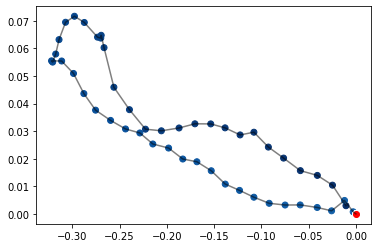

In [17]:
i = 1

plt.plot(y.numpy()[i,0,:], y.numpy()[i,1,:], c = 'black', alpha = 0.5)
plt.scatter(y.numpy()[i,0,:], y.numpy()[i,1,:], c=np.arange(256), cmap='Blues_r')
plt.scatter(0,0, c = 'red')

## deep networks

In [18]:
import torch
from torch import nn
from torch import optim
import torchvision as tv
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [29]:
class LSTMGenerator(nn.Module):
    """An LSTM based generator. It expects a sequence of noise vectors as input.
    Args:
        in_dim: Input noise dimensionality
        out_dim: Output dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Input: noise of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, out_dim)
    """

    def __init__(self):
        super().__init__()

        self.covariable_encoder = nn.Sequential(nn.BatchNorm1d(6), 
                                                nn.Linear(9*7, 256))
        
        self.lstm = nn.LSTM(input_size=7, hidden_size = 2,
                            num_layers = 5, batch_first=True)
        
        self.activation = nn.Sequential(nn.Tanh())

    def forward(self, x, z):
        # get batch_size
        batch_size = z.size(1)
        
        # covariable maps as vector  (seq_len, batch, input_size)
        out = x.reshape((12, 6, 9*7))
        out = self.covariable_encoder(out)
        out = out.reshape((256, 12, 6))

        # concatenate noise and condition
        out = torch.cat((out,z), axis = 2)

        # init LSTM cells (num_layers, batch, hidden_size)
        out, _ = self.lstm(out)
        out = self.activation(out)

        # out = self.linear(out.contiguous().view(batch_size*self.seq_len, self.hidden_dim))
        return out

In [30]:
gen = LSTMGenerator()
z = torch.rand((256, batch_size, 1)) # (len, batch, features)

out = gen(x,z)
out.shape

torch.Size([256, 12, 2])

In [32]:
y = y.view(256,12,2)

In [62]:
class LSTMDiscriminator(nn.Module):
    """An LSTM based discriminator. It expects a sequence as input and outputs a probability for each element. 
    Args:
        in_dim: Input noise dimensionality
        n_layers: number of lstm layers
        hidden_dim: dimensionality of the hidden layer of lstms
    Inputs: sequence of shape (batch_size, seq_len, in_dim)
    Output: sequence of shape (batch_size, seq_len, 1)
    """

    def __init__(self):
        super().__init__()

        self.covariable_encoder = nn.Sequential(nn.BatchNorm1d(6), 
                                                nn.Linear(9*7, 256))
        self.lstm = nn.LSTM(8, 64, 5, batch_first=True)
        self.linear = nn.Sequential(nn.Linear(256*64, 1), 
                                    nn.Sigmoid())

    def forward(self, x,y):        
        # covariable maps as vector  (seq_len, batch, input_size)
        out = x.reshape((12, 6, 9*7))
        out = self.covariable_encoder(out)
        out = out.reshape((256, 12, 6))

        # concatenate noise and condition
        out = torch.cat((out,y), axis = 2)

        # init LSTM cells (num_layers, batch, hidden_size)
        out, _ = self.lstm(out)
        out = self.linear(out.contiguous().view(batch_size, 256*64))
        return out


In [63]:
dis = LSTMDiscriminator()

In [64]:
dis(x,y).shape

torch.Size([12, 1])

# training

In [78]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 12
generator = LSTMGenerator().to(device)
discriminator = LSTMDiscriminator().to(device)

criterion = nn.BCELoss()
mse = nn.MSELoss()

optim_d = optim.Adam(discriminator.parameters(), lr=0.001)
optim_g = optim.Adam(generator.parameters(),lr=0.001)

target_ones = torch.ones((batch_size, 1), device=device)
target_zeros = torch.zeros((batch_size, 1), device=device)

In [79]:
# Train the model
nb_epoch = 10

for epoch in range(nb_epoch):
    i = 0
    loss_g_running, loss_d_real_running, loss_d_fake_running = 0, 0, 0
    for batch, (x, y) in enumerate(train_loader):
        
        i+= 1

        #### TRAIN DISCRIMINATOR
        ## true samples
        y = y.view(256,12,2)
        x = x.to(device)
        y = y.to(device) 

        discriminator.zero_grad()
        pred_real = discriminator(x,y)
        loss_real = criterion(pred_real, target_ones)

        ## false samples
        z = torch.rand((256, batch_size, 1), device=device) 
        with torch.no_grad():
            fake_samples = generator(x,z)
        pred_fake = discriminator(x, fake_samples)
        loss_fake = criterion(pred_fake, target_zeros)
        
        # combine
        loss = (loss_real + loss_fake) / 2
        loss.backward()
        optim_d.step()

        loss_d_real_running += loss_real.item()
        loss_d_fake_running += loss_fake.item()
        
        #### TRAIN GENERATOR
        generator.zero_grad()
        z = torch.rand((256, batch_size, 1), device=device) 

        generated = generator(x,z)
        classifications = discriminator(x, generated)
        loss = criterion(classifications, target_ones) + mse(generated, y)
        loss.backward()
        optim_g.step()

        loss_g_running += loss.item()
      
    print('Epoch [{}/{}] -----------------------------------------------------------------------------'
        .format(epoch+1, nb_epoch, i, len(train_loader)))
    print('G: {}, Dr : {}, Df : {}'
        .format(loss_g_running, loss_d_real_running, loss_d_fake_running))

            # ldr_, ldf_ = self.train_step_discriminator(real_samples)


Epoch [1/10] -----------------------------------------------------------------------------
G: 16.599422097206116, Dr : 14.621918857097626, Df : 14.748816460371017
Epoch [2/10] -----------------------------------------------------------------------------
G: 32.10065537691116, Dr : 11.9892544336617, Df : 10.87070157006383
Epoch [3/10] -----------------------------------------------------------------------------
G: 605.6558384895325, Dr : 0.0022285318006733945, Df : 0.00452286706733851
Epoch [4/10] -----------------------------------------------------------------------------
G: 1253.9547480940819, Dr : 0.001030731535255569, Df : 4.336185455322266
Epoch [5/10] -----------------------------------------------------------------------------
G: 842.9631390571594, Dr : 12.997327028853046, Df : 6.381664867870631
Epoch [6/10] -----------------------------------------------------------------------------
G: 861.7390823364258, Dr : 0.9910271951384928, Df : 0.0
Epoch [7/10] ---------------------------

## visualizing

In [80]:
generated.shape

torch.Size([256, 12, 2])

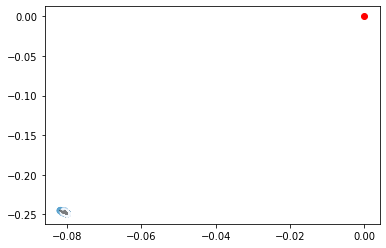

In [81]:
i = 2

traj = generated.detach().numpy()

plt.plot(traj[:,i,0], traj[:,i,1], c = 'black', alpha = 0.5)
plt.scatter(traj[:,i,0], traj[:,i,1], c=np.arange(256), cmap='Blues_r')
plt.scatter(0,0, c = 'red')